maths for transformers

In [1]:
import torch
import torch.nn.functional as F
import math

import matplotlib.pyplot as plt
import numpy as np

## Linear Algebra

### 1. Dot Product (Inner Product, Scalar Product)

In [ ]:
# dot product

# same direction
a = torch.tensor([1.0, 2.0])
b = torch.tensor([2.0, 3.0])
print(f"Same direction: {torch.dot(a, b)}")

# opposite direction
c = torch.tensor([1.0, 0.0])
d = torch.tensor([-2.0, 0.0])
print(f"Opposite direction: {torch.dot(c, d)}")

# perpendicular
e = torch.tensor([1.0, 0.0])
f = torch.tensor([0.0, 3.0])
print(f"Perpendicular: {torch.dot(e, f)}")

In [ ]:
a_norm = a / torch.norm(a)
b_norm = b / torch.norm(b)
cos_sim = torch.dot(a_norm, b_norm)
print(f"Cosine similarity: {cos_sim}")

The dot product $\vec{u} \cdot \vec{v} = u_1 v_1 + u_2 v_2 + \dots + u_n v_n = \sum_{i=1}^{n} u_i v_i = \|\vec{u}\| \|\vec{v}\| \cos(\theta)$:

* where $\|\vec{u}\|$ represents the magnitude (length) of a vector
* $\vec{u} \cdot \vec{v} = 0$ iff $\vec{u} \perp \vec{v}$ (orthogonal vectors encode independent, uncorrelated information, as if they live in separate dimensions.)
* $\vec{u} \cdot \vec{v} > 0$ → angle $< 90^\circ$ (vectors point in generally the same direction)
* $\vec{u} \cdot \vec{v} < 0$ → angle $> 90^\circ$ (vectors point in generally opposite directions)
* $\vec{u} \cdot \vec{v}$ represents the scalar resulting from orthogonal projection that $\vec{u}$ casts onto $\vec{v}$. In other words, $\vec{u}$ projects a shadow $L$ onto $\vec{v}$ such that $\vec{u} \cdot \vec{v} = L \|\vec{v}\|$ (a scalar).

    * Let $\theta$ be the angle between $\vec{u}$ and $\vec{v}$.
        * Then, $\cos \theta = L / \|\vec{u}\|$,
          <br>so $\|\vec{u}\| \cos \theta = L$.

    * Let $\beta$ be the angle between $\vec{u}$ and the **x-axis**, and $\alpha$ be the angle between $\vec{v}$ and the **x-axis**.
        * Such that:

          $\sin(\alpha) = v_2 / \|\vec{v}\|$, $\quad \sin(\beta) = u_2 / \|\vec{u}\|$

          $\cos(\alpha) = v_1 / \|\vec{v}\|$, $\quad \cos(\beta) = u_1 / \|\vec{u}\|$
        * Then,

            $\cos \theta = \cos(\beta - \alpha)$

            $= \cos(\beta)\cos(\alpha) + \sin(\beta)\sin(\alpha)$

            $= \frac{u_1 v_1}{\|\vec{u}\| \|\vec{v}\|} + \frac{u_2 v_2}{\|\vec{u}\| \|\vec{v}\|} = \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\| \|\vec{v}\|}$

    * Therefore, $\vec{u} \cdot \vec{v} = \|\vec{u}\| \|\vec{v}\| \cos(\theta) = \|\vec{u}\| \|\vec{v}\| \cdot \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\| \|\vec{v}\|} = u_1 v_1 + u_2 v_2$.

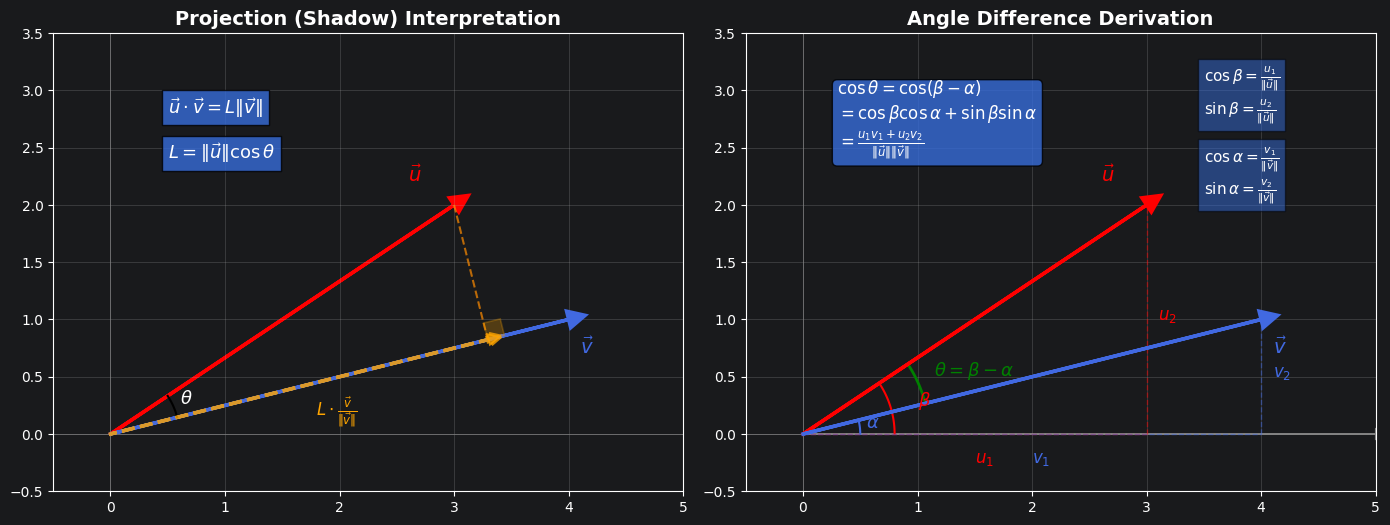

In [76]:
# plt practice

u = np.array([3.0, 2.0])
v = np.array([4.0, 1.0])

dot_product = np.dot(u, v)

norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)

alpha = np.arctan2(v[1], v[0])  # angle of v
beta = np.arctan2(u[1], u[0])   # angle of u

L = dot_product / norm_v
proj_u_on_v = L * (v / norm_v) # L (scalar) in the direction of v: vector

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
ax1.set_xlim(-0.5, 5)
ax1.set_ylim(-0.5, 3.5)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.5)

# --- LEFT SUBPLOT: SHADOW ---

# vector v (the RHS vector that receives the shadow)
ax1.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15,
          fc='royalblue', ec='royalblue', linewidth=2.5, zorder=2)
ax1.text(v[0] + 0.1, v[1] - 0.3, r'$\vec{v}$', fontsize=14, color='royalblue')

# vector u (the vector casting the shadow)
ax1.arrow(0, 0, u[0], u[1], head_width=0.15, head_length=0.15,
          fc='red', ec='red', linewidth=2.5, zorder=1)
ax1.text(u[0] - 0.4, u[1] + 0.2, r'$\vec{u}$', fontsize=14, color='red')

# the projection of u onto v (the shadow)
ax1.arrow(0, 0, proj_u_on_v[0], proj_u_on_v[1], head_width=0.12, head_length=0.12,
          fc='orange', ec='orange', linewidth=2.5, alpha=0.8, zorder=3,
          linestyle='--')
mid_proj = proj_u_on_v / 2
ax1.text(mid_proj[0] + 0.15, mid_proj[1] - 0.25, r'$L \cdot \frac{\vec{v}}{\|\vec{v}\|}$',
         fontsize=12, color='orange')

# tip of u drops to projection
tip_u = u
perp = tip_u - proj_u_on_v  # component of u perpendicular to v
ax1.plot([tip_u[0], proj_u_on_v[0]], [tip_u[1], proj_u_on_v[1]],
         '--', color='darkorange', linewidth=1.5, alpha=0.7)

# mark the right angle
v_dir = v / norm_v           # unit vector along v
perp_dir = perp / np.linalg.norm(perp)  # unit vector perpendicular to v
square_size = 0.15

square_pts = np.array([
    proj_u_on_v,
    proj_u_on_v + square_size * v_dir,
    proj_u_on_v + square_size * v_dir + square_size * perp_dir,
    proj_u_on_v + square_size * perp_dir
])

ax1.fill(square_pts[:, 0], square_pts[:, 1],
        facecolor='orange', edgecolor='orange',
        alpha=0.25, linewidth=1.2, zorder=4)

# craw angle theta arc
arc_radius = 0.6
arc_theta = np.linspace(alpha, beta, 50)
ax1.plot(arc_radius * np.cos(arc_theta), arc_radius * np.sin(arc_theta),
         'k-', linewidth=1.5)
mid_angle = (alpha + beta) / 2
ax1.text(1.1 * arc_radius * np.cos(mid_angle), 1.1 * arc_radius * np.sin(mid_angle),
         r'$\theta$', fontsize=13)

ax1.annotate(
    r'$\vec{u} \cdot \vec{v} = L\|\vec{v}\|$',
    xy=(0.5, 2.8), fontsize=13,
    bbox=dict(alpha=0.8))
ax1.annotate(
    r'$L = \|\vec{u}\|\cos\theta$',
    xy=(0.5, 2.4), fontsize=13,
    bbox=dict(alpha=0.8))

ax1.set_title('Projection (Shadow) Interpretation', fontsize=14, fontweight='bold')

# --- RIGHT SUBPLOT: ANGLES ---

ax2 = axes[1]
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(-0.5, 3.5)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.axvline(x=0, color='gray', linewidth=0.5)

# draw x-axis
ax2.arrow(0, 0, 5, 0, head_width=0.1, head_length=0.1, fc='gray', ec='gray', linewidth=1)

# vector u
ax2.arrow(0, 0, u[0], u[1], head_width=0.15, head_length=0.15,
          fc='red', ec='red', linewidth=2.5, zorder=3)
ax2.text(u[0] - 0.4, u[1] + 0.2, r'$\vec{u}$', fontsize=14, color='red')

# vector v
ax2.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15,
          fc='royalblue', ec='royalblue', linewidth=2.5, zorder=3)
ax2.text(v[0] + 0.1, v[1] - 0.3, r'$\vec{v}$', fontsize=14, color='royalblue')

# angle beta (u with x-axis)
arc_beta = np.linspace(0, beta, 50)
ax2.plot(0.8 * np.cos(arc_beta), 0.8 * np.sin(arc_beta), color='red', linewidth=1.5)
ax2.text(1.0, 0.25, r'$\beta$', fontsize=13, color='red')

# angle alpha (v with x-axis)
arc_alpha = np.linspace(0, alpha, 50)
ax2.plot(0.5 * np.cos(arc_alpha), 0.5 * np.sin(arc_alpha), color='royalblue', linewidth=1.5)
ax2.text(0.55, 0.05, r'$\alpha$', fontsize=13, color='royalblue')

# Draw angle theta = beta - alpha
arc_theta = np.linspace(alpha, beta, 50)
ax2.plot(1.1 * np.cos(arc_theta), 1.1 * np.sin(arc_theta), color='green', linewidth=2)
mid_theta = (alpha + beta) / 2
ax2.text(1.25 * np.cos(mid_theta), 1.25 * np.sin(mid_theta),
         r'$\theta = \beta - \alpha$', color='green', fontsize=13)

# components of u
# u1 (horizontal)
ax2.plot([0, u[0]], [0, 0], '--', color='red', alpha=0.5, linewidth=1)
ax2.text(u[0]/2, -0.25, r'$u_1$', fontsize=12, color='red')
# u2 (vertical)
ax2.plot([u[0], u[0]], [0, u[1]], '--', color='red', alpha=0.5, linewidth=1)
ax2.text(u[0] + 0.1, u[1]/2, r'$u_2$', fontsize=12, color='red')

# components of v
# v1 (horizontal)
ax2.plot([0, v[0]], [0, 0], '--', color='royalblue', alpha=0.5, linewidth=1)
ax2.text(v[0]/2, -0.25, r'$v_1$', fontsize=12, color='royalblue')
# v2 (vertical)
ax2.plot([v[0], v[0]], [0, v[1]], '--', color='royalblue', alpha=0.5, linewidth=1)
ax2.text(v[0] + 0.1, v[1]/2, r'$v_2$', fontsize=12, color='royalblue')

# annotations
ax2.annotate(
    r'$\cos\beta = \frac{u_1}{\|\vec{u}\|}$' + '\n' +
    r'$\sin\beta = \frac{u_2}{\|\vec{u}\|}$',
    xy=(3.5, 2.8), fontsize=11,
    bbox=dict(alpha=0.5),
)

ax2.annotate(
    r'$\cos\alpha = \frac{v_1}{\|\vec{v}\|}$' + '\n' +
    r'$\sin\alpha = \frac{v_2}{\|\vec{v}\|}$',
    xy=(3.5, 2.1), fontsize=11,
    bbox=dict(alpha=0.5)
)

ax2.annotate(
    r'$\cos\theta = \cos(\beta - \alpha)$' + '\n' +
    r'$= \cos\beta\cos\alpha + \sin\beta\sin\alpha$' + '\n' +
    r'$= \frac{u_1 v_1 + u_2 v_2}{\|\vec{u}\|\|\vec{v}\|}$',
    xy=(0.3, 2.5), fontsize=12,
    bbox=dict(boxstyle='round,pad=0.3', alpha=0.8))

ax2.set_title('Angle Difference Derivation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.1 Dot Product in Attention

In [10]:
# dot product in attention
d_k = 64

# two random vectors in high dimensions
q = torch.randn(d_k)
k = torch.randn(d_k)

# unscaled dot product can be quite large
raw = torch.dot(q, k)
print(f"Raw dot product: {raw:.2f}")

# scaled: divide by sqrt(d_k)
scaled = raw / (d_k ** 0.5)
print(f"Scaled: {scaled:.2f}")

Raw dot product: 7.19
Scaled: 0.90


In self-attention, `Q @ K^T` computes the dot product between every query and every key, measuring relevance.

But attention needs a probability distribution over tokens -- every value between 0 and 1, all summing to 1. Softmax does this by amplifying the largest values and suppressing the rest.

`sqrt(d_k)` scaling factor in attention exists because of this dot product interpretation: as `d_k` (the key/query dimension) grows, the variance of the dot product grows proportionally, pushing the softmax into regions with extremely small gradients.

For a vector $z = [z_1, z_2, \dots, z_n]$:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$$

In [4]:
# softmax quick test

# raw attention scores for one query attending to 4 keys
scores = torch.tensor([2.0, 1.0, -3.0, 0.5])

exp_scores = torch.exp(scores)
print("exponentiated:", exp_scores)
print("sum:", exp_scores.sum())

softmax_manual = exp_scores / exp_scores.sum()
print("manual softmax:", softmax_manual)

# PyTorch version
softmax_torch = F.softmax(scores, dim=-1)
print("PyTorch softmax:", softmax_torch)

exponentiated: tensor([7.3891, 2.7183, 0.0498, 1.6487])
sum: tensor(11.8058)
manual softmax: tensor([0.6259, 0.2302, 0.0042, 0.1397])
PyTorch softmax: tensor([0.6259, 0.2302, 0.0042, 0.1397])


* Exponentiation creates positivity. No matter how negative the input, `e^z > 0`. No matter how positive, `e^z < ∞`.
* The denominator normalizes. Dividing by the sum forces all outputs to sum to 1.

In [14]:
scores_moderate = torch.tensor([2.0, 1.0, -3.0, 0.5])
scores_extreme  = torch.tensor([20.0, 10.0, -30.0, 5.0])  # x10 shift

print("Moderate scores:", F.softmax(scores_moderate, dim=-1))
print("Extreme scores: ", F.softmax(scores_extreme, dim=-1))

Moderate scores: tensor([0.6259, 0.2302, 0.0042, 0.1397])
Extreme scores:  tensor([9.9995e-01, 4.5398e-05, 1.9287e-22, 3.0589e-07])


* The scores have the same relative ordering, but the softmax output on extreme values is more peaked -- it concentrates probability mass on the winner.

In [11]:
# simulate Q @ K^T for one query against 4 keys
torch.manual_seed(123)
scores = torch.randn(4) * math.sqrt(d_k)  # variance ~ d_k
print("Unscaled scores:", scores)
print("Unscaled softmax:", F.softmax(scores, dim=-1))

# scale down
scores_scaled = scores / math.sqrt(d_k)
print("\nScaled scores:", scores_scaled)
print("Scaled softmax:", F.softmax(scores_scaled, dim=-1))

Unscaled scores: tensor([-0.8917,  0.9629, -2.9571, -1.9233])
Unscaled softmax: tensor([0.1270, 0.8116, 0.0161, 0.0453])

Scaled scores: tensor([-0.1115,  0.1204, -0.3696, -0.2404])
Scaled softmax: tensor([0.2556, 0.3223, 0.1974, 0.2247])


* Without scaling, one token hogs 81% of attention. The model can't learn nuanced patterns when every attention head collapses to a near one-hot vector. With scaling, the distribution stays softer, and gradients flow to all positions.

### 2. Matrix Multiplication

In [78]:
A = torch.randn(3, 4)
B = torch.randn(4, 2)
C = A @ B

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"C shape: {C.shape}")

A shape: torch.Size([3, 4])
B shape: torch.Size([4, 2])
C shape: torch.Size([3, 2])


In [81]:
# view: each entry C[i, j] is the dot product of row i of A with column j of B
manual_entry = torch.dot(A[1, :], B[:, 0])
print(f"C[1, 0] from matmul: {C[1, 0]:.6f}")
print(f"dot(A[1,:], B[:,0]): {manual_entry:.6f}")

C[1, 0] from matmul: -1.127403
dot(A[1,:], B[:,0]): -1.127403


In [83]:
# view: each column of C is a weighted sum of columns of A, with weights from the corresponding column of B
reconstructed_col0 = torch.zeros(3)
for k in range(4):  # for each column of A
    reconstructed_col0 += B[k, 0] * A[:, k]

print(f"Original C[:, 0]:      {C[:, 0]}")
print(f"Reconstructed C[:, 0]: {reconstructed_col0}")

Original C[:, 0]:      tensor([ 0.7455, -1.1274,  0.8812])
Reconstructed C[:, 0]: tensor([ 0.7455, -1.1274,  0.8812])


In [87]:
# matrix multiplication as a transformation
theta = np.pi / 4  # 45 degrees
rotation = torch.tensor([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
], dtype=torch.float32)

x = torch.tensor([1.0, 0.0])
rotated = rotation @ x

print(f"Original: {x}")
print(f"Rotated:  {rotated}")

Original: tensor([1., 0.])
Rotated:  tensor([0.7071, 0.7071])


A transformation (or function or mapping) T from ℝⁿ to ℝᵐ is a rule that assigns to each vector $\vec x$ in ℝⁿ to a vector T(x) in ℝᵐ

T is **linear** if it satisfies two properties:
1. T($\vec{u}$ + $\vec{v}$) = T($\vec{u}$) + T($\vec{v}$) -- preserves addition
2. T(*k*·$\vec{u}$) = *k*·T($\vec{u}$) -- preserves scalar multiplication.
for all $\vec{u}$, $\vec{v}$ in ℝⁿ and all scalars *k*

Every linear transformation (rotation, scaling, projection, reflection, shearing) can be expressed as a matrix multiplication.
> Let T be a linear transformation from ℝⁿ to ℝᵐ. Then there exists a unique matrix A such that T(x^) = A @ x^ for all x^ in ℝⁿ.

#### 2.1 In Transformers

Every weight matrix in a transformer is a learned linear transformation:
* **W_Q, W_K, W_V**: project token representation into query, key, and value spaces
* **W_O**: project the concatenated attention output back to model dimension
* **FFN matrices**: transform representations within each token position

For example, `W_Q @ x` applies a learned transformation that rotates and scales the token's representation into "query space" -- a space optimized for computing similarity with key vectors.

The operation `attn_weights @ V` is also a linear transformation. Each output row is a weighted combination (linear combination) of the value vectors, with the attention weights providing the mixing coefficients.

In [10]:
# single-head attention

Q = torch.tensor([
    [1.0, 0.0, 1.0],   # token 0 query
    [0.0, 1.0, 1.0]    # token 1 query
])
print("Q:\n", Q)
print("  Row 0 = query vector for token 0:", Q[0])
print("  Row 1 = query vector for token 1:", Q[1])

K = torch.tensor([
    [1.0, 0.0, 1.0],   # token 0 key
    [0.0, 1.0, 1.0]    # token 1 key
])
print("K:\n", K)
print("  Row 0 = key vector for token 0:", K[0])
print("  Row 1 = key vector for token 1:", K[1])

# transpose K to make columns into rows
K_T = K.transpose(-2, -1)

print("K^T:\n", K_T)
print("  Column 0 = key vector for token 0:", K_T[:, 0])
print("  Column 1 = key vector for token 1:", K_T[:, 1])

#  scores[i, j] = dot product of Q[i] (row) with K.T[:, j] (column)
#               = dot product of query i with key j
#               = "how much should token i attend to token j?"
scores = Q @ K_T
print("Scores:\n", scores)

Q:
 tensor([[1., 0., 1.],
        [0., 1., 1.]])
  Row 0 = query vector for token 0: tensor([1., 0., 1.])
  Row 1 = query vector for token 1: tensor([0., 1., 1.])
K:
 tensor([[1., 0., 1.],
        [0., 1., 1.]])
  Row 0 = key vector for token 0: tensor([1., 0., 1.])
  Row 1 = key vector for token 1: tensor([0., 1., 1.])
K^T:
 tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])
  Column 0 = key vector for token 0: tensor([1., 0., 1.])
  Column 1 = key vector for token 1: tensor([0., 1., 1.])
Scores:
 tensor([[2., 1.],
        [1., 2.]])


In [19]:
# after softmax, we get attention weights, then compute context via:
attn = torch.tensor([
    [0.7, 0.3],   # token 0 attends 70% to token 0, 30% to token 1
    [0.3, 0.7]    # token 1 attends 30% to token 0, 70% to token 1
])  # Shape: (2, 2)

V = torch.tensor([
    [1.0, 2.0, 3.0],   # value for token 0
    [4.0, 5.0, 6.0]    # value for token 1
])  # Shape: (2, 3)

output = attn @ V  # (2, 2) @ (2, 3) -> (2, 3)

print("\nToken 0 is a weighted blend of all value vectors:")
print(f"  attn[0][0] * V[0] + attn[0][1] * V[1]")
print(f"  = {attn[0, 0]:.1f} * {V[0].tolist()} + {attn[0, 1]:.1f} * {V[1].tolist()}")
print(f"  = {[round(v, 2) for v in output[0].tolist()]}")


Token 0 is a weighted blend of all value vectors:
  attn[0][0] * V[0] + attn[0][1] * V[1]
  = 0.7 * [1.0, 2.0, 3.0] + 0.3 * [4.0, 5.0, 6.0]
  = [1.9, 2.9, 3.9]


In [34]:
# feedforward network: x (d_model) → Linear(d_model, d_ff) → non-linear activation function → Linear(d_ff, d_model) → output (d_model)

d_model = 2  # model dimension, small for visibility
d_ff = 3     # feed-forward hidden dimension (usually 4x d_model)

# a token vector (after attention + residual + layer norm)
x = torch.tensor([0.8, 0.5])
print(f"Input token x: {x}")

W1 = torch.tensor([
    [ 1.5,  0.0],   # row 0: scale x_1 by 1.5, ignore x_2
    [ 0.0, -0.8],   # row 1: ignore x_1, scale and flip x_2
    [ 1.0,  1.0]    # row 2: sum x_1 and x_2
])
print(f"W1 shape `(d_ff, d_model) -- (output_dim, input_dim)`: {W1.shape}")

# the transformation
h_pre_act = W1 @ x         # (3, 2) @ (2,) → (3,)
h = torch.relu(h_pre_act)  # ReLU zeros out negative values
print(f"\nW₁ @ x:        {h_pre_act}")
print(f"After ReLU:    {h}")

# second linear transformation
W2 = torch.tensor([
    [ 0.5, -0.3,  0.8],   # row 0: weighted combination of h's dimensions → output dim 0
    [ 0.2,  0.7, -0.4]    # row 1: weighted combination of h's dimensions → output dim 1
])
output = W2 @ h           # (2, 3) @ (3,) → (2,)
print(f"\nW₂ shape:      {W2.shape}")   # (d_model, d_ff) = (2, 3)
print(f"W₂ @ h:        {output}")
print(f"Output shape:  {output.shape}") # (2,) -- back to d_model

Input token x: tensor([0.8000, 0.5000])
W1 shape `(d_ff, d_model) -- (output_dim, input_dim)`: torch.Size([3, 2])

W₁ @ x:        tensor([ 1.2000, -0.4000,  1.3000])
After ReLU:    tensor([1.2000, 0.0000, 1.3000])

W₂ shape:      torch.Size([2, 3])
W₂ @ h:        tensor([ 1.6400, -0.2800])
Output shape:  torch.Size([2])


* In transformers' feed forward network, $W_1$ and $W_2$ are learned matrices--randomly initialized then specialized through gradient descent during training.
* The former expands input x to give the model more dimensions (typically 4x) to work with -- more feature detectors, each asking how much does the input align with this learned direction.
* A nonlinear activation function between $W_1$ and $W_2$ breaks the chain of linear operations. Without it, `W_2 @ (W_1 @ x)` would collapse into `(W_2 @ W_1) @ x` -- a single matrix -- making the expansion pointless. This nonlinearity breaks the chain, giving the FFN the capacity to learn complex, non-linear transformations.
* The latter contracts back to the original size so the output can be added via residual connection.

Note: Bias terms (not shown) are added to all linear projections i.e., `W_Q @ x + b_Q`. This introduces a learned baseline per output dimension and makes the transformation affine (no longer forced through the origin)

#### 2.2 In Tandem with Other Operations

In [42]:
# activation functions

x = torch.tensor([-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0])
print(f"Input: {x}")

# Rectified Linear Unit: ReLU(x) = max(0, x), original transformer
relu_out = F.relu(x)
print(f"ReLU:  {relu_out}")

# Gaussian Error Linear Unit: GELU(x) ≈ x ⋅ Φ(x), vision transformers
# where Φ(x) is the cumulative distribution function of the standard normal
gelu_out = F.gelu(x)
print(f"GELU:  {gelu_out}")

# Swish-Gated Linear Unit: SwiGLU(x) = linear(x) ⋅ sigmoid(gate(x))
swish = lambda x: x * torch.sigmoid(x)
swish_out = swish(x)
print(f"Swish: {swish_out}")

Input: tensor([-2.0000, -1.0000, -0.5000,  0.0000,  0.5000,  1.0000,  2.0000])
ReLU:  tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5000, 1.0000, 2.0000])
GELU:  tensor([-0.0455, -0.1587, -0.1543,  0.0000,  0.3457,  0.8413,  1.9545])
Swish: tensor([-0.2384, -0.2689, -0.1888,  0.0000,  0.3112,  0.7311,  1.7616])


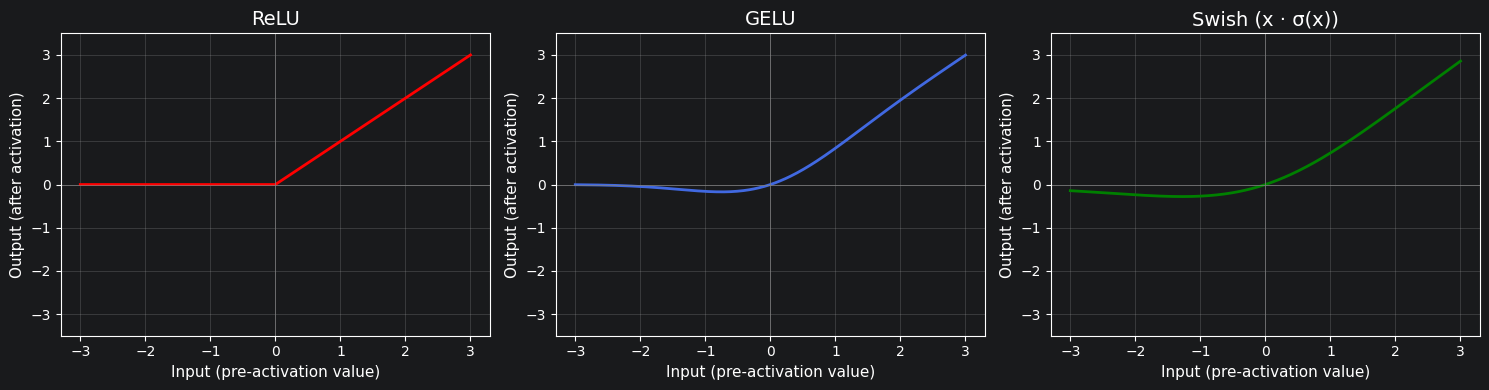

In [8]:
x_plot = torch.linspace(-3, 3, 300) # example outputs from W @ x

activations = [
    ('ReLU',              lambda x: F.relu(x),              'red'),
    ('GELU',              lambda x: F.gelu(x),              'royalblue'),
    ('Swish (x · σ(x))',  lambda x: x * torch.sigmoid(x),   'green'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, fn, color) in zip(axes, activations):
    ax.plot(x_plot, fn(x_plot), linewidth=2, color=color)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Input (pre-activation value)', fontsize=11)
    ax.set_ylabel('Output (after activation)', fontsize=11)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* The output (y) is now non-linear. The relationship between input and output changes depending on where you are on the curve
* ReLU completely kills negative signals (gradient = 0). GELU and Swish preserve a small negative output, which means gradient can still flow during backpropagation
* All three converge to y = x for large positive inputs -- the nonlinearity matters most near zero and in the negative region

In [21]:
# broadcasting

# residuals i.e., x + pe
batch_size, seq_len, d_model = 2, 5, 8

x  = torch.randn(batch_size, seq_len, d_model)   # (2, 5, 8)
pe = torch.randn(1, seq_len, d_model)            # (1, 5, 8) -- stored with batch=1

output = x + pe
print(f"a:           {x.shape}")
print(f"b:           {pe.shape}")
print(f"a + b shape: {output.shape}\n")

# sinusoidal encoding position * div_term
max_seq_len, hidden_size = 10, 6
position = torch.arange(0, max_seq_len).unsqueeze(1)
div_term = torch.tensor([1.0, 0.1, 0.01])
angles = position * div_term

print(f"c:     {position.shape}")
print(f"d:     {div_term.shape}")
print(f"c * d: {angles.shape}")


a:           torch.Size([2, 5, 8])
b:           torch.Size([1, 5, 8])
a + b shape: torch.Size([2, 5, 8])

c:     torch.Size([10, 1])
d:     torch.Size([3])
c * d: torch.Size([10, 3])


[docs](https://docs.pytorch.org/docs/2.12/notes/broadcasting.html0)
* element-wise: align from right, dims must be equal, 1, or does not exist
* matrix multiplication case (`@`): strip last 2 dims, broadcast the rest, then matmul

In [34]:
examples = [
    ("matching batch dims",  (4, 2, 3), (4, 3, 5)),
    ("broadcasting batch",   (4, 2, 3), (1, 3, 5)),
    ("multi-dim batch dims", (2, 3, 4, 5), (2, 3, 5, 6)),
    ("broadcasting both",    (2, 1, 4, 5), (1, 3, 5, 6)),
    ("missing batch dim",   (4, 2, 3), (3, 5)),
]

for name, shape_a, shape_b in examples:
    A = torch.randn(shape_a)
    B = torch.randn(shape_b)
    C = A @ B
    print(f"{name:20s}  {str(shape_a):12s} @ {str(shape_b):13s} → {C.shape}")

matching batch dims   (4, 2, 3)    @ (4, 3, 5)     → torch.Size([4, 2, 5])
broadcasting batch    (4, 2, 3)    @ (1, 3, 5)     → torch.Size([4, 2, 5])
multi-dim batch dims  (2, 3, 4, 5) @ (2, 3, 5, 6)  → torch.Size([2, 3, 4, 6])
broadcasting both     (2, 1, 4, 5) @ (1, 3, 5, 6)  → torch.Size([2, 3, 4, 6])
missing batch dim     (4, 2, 3)    @ (3, 5)        → torch.Size([4, 2, 5])


In [7]:
# transpose, shape alignment operation

seq_len, d_k = 4, 3

# in attention, Q, K, and V take shape (seq_len, d_k)
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)

try:
    Q @ K
except RuntimeError as e:
    print(f"Q @ K error: {e}")

K_T = K.transpose(-2, -1) # swaps the last two dimensions, turning rows into columns
scores = Q @ K_T
print("After transpose (Q @ K^T): \n", scores)

Q @ K error: mat1 and mat2 shapes cannot be multiplied (4x3 and 4x3)
After transpose (Q @ K^T): 
 tensor([[-0.6963,  0.0582,  1.2703,  1.6165],
        [-2.0102, -0.6930, -0.3105, -0.5357],
        [-1.0417, -0.7576,  0.1567, -1.4066],
        [ 1.0663,  0.1597,  0.4162, -0.2543]])


A matrix multiplication computes many dot products simultaneously. When the transformer computes `Q @ K^T`, it's computing `seq_len²` dot products in one operation. But transformers don't process one sequence at a time -- they process a batch of sequences, and often with multiple attention heads. On a GPU, this all happens in parallel (having to do with mapping to hardware, CUDA).

In [36]:
# matrix multiplication in batches
batch_size, num_heads, seq_len, d_k = 32, 8, 128, 64

Q = torch.randn(batch_size, num_heads, seq_len, d_k)
K = torch.randn(batch_size, num_heads, seq_len, d_k)

scores = Q @ K.transpose(-2, -1)

print(f"Q shape:            {Q.shape}")
print(f"K.T shape:          {K.transpose(-2, -1).shape}")
print(f"Scores shape:       {scores.shape}")
print(f"Total dot products: {batch_size * num_heads * seq_len * seq_len}")
print()

# each `[batch, head]` slice is an independent [128, 128] attention score matrix
print("Batch 0, Head 0 scores:\n", scores[0, 0])
print("\nBatch 0, Head 1 scores:\n", scores[0, 1])
print("\nBatch 1, Head 0 scores:\n", scores[1, 0])

Q shape:            torch.Size([32, 8, 128, 64])
K.T shape:          torch.Size([32, 8, 64, 128])
Scores shape:       torch.Size([32, 8, 128, 128])
Total dot products: 4194304

Batch 0, Head 0 scores:
 tensor([[-11.1624,  -0.8751,  -1.6225,  ...,  14.6345,  10.1286, -11.1251],
        [  6.9052,  11.5933,  -3.0164,  ...,  19.4440, -12.7175,   0.7186],
        [ -7.7704,  -6.7574,  12.2735,  ...,   5.8850,   7.8494,  -6.6756],
        ...,
        [ -7.0138,  -0.6983,  -2.1166,  ...,   1.7844,   6.1030,  -7.2390],
        [  1.4130,   7.6091, -13.8027,  ...,   8.5623,  -7.4886,   4.8299],
        [-10.1472,   6.7731,  -2.8330,  ...,  -2.7218,   1.1093, -10.5129]])

Batch 0, Head 1 scores:
 tensor([[  4.9025,   8.8682,  11.3951,  ...,  -1.0310,  -0.8519,   4.9720],
        [-11.8599,  -7.4413,   0.4100,  ...,  -0.8238, -14.9636,  -7.3970],
        [  0.9269, -19.3510,  -8.8035,  ...,  -2.2134,   2.3831,  -0.1227],
        ...,
        [ -8.2135,  19.3117,   3.7796,  ...,  -7.1195,   2.51

#### 2.4 CUDA

In [ ]:
# 2d vs 3c vs 4d vs nd

In [ ]:
# goal: https://tensara.org/problems/matmul-4d

### 3. Linear Algebra Foundations

#### 3.1 Subspaces

A **linear combination** of the vectors $\{\vec{v}_1, \vec{v}_2, \dots, \vec{v}_n\}$ is the expression $c_1\vec{v}_1 + c_2\vec{v}_2 + \dots + c_n\vec{v}_n$ where $c_1, c_2, \dots, c_n$ are scalars.

A set $\{\vec{u}_1, \vec{u}_2, \dots, \vec{u}_n\}$ of vectors in a space $V$ is said to **span** $V$ if every vector $\vec{v}$ in $V$ can be written as a linear combination of the vectors in the set; that is, there exist scalars $c_1, c_2, \dots, c_n$ such that $\vec{v} = c_1\vec{u}_1 + c_2\vec{u}_2 + \dots + c_n\vec{u}_n$

The **row space** of a matrix *A* of size *m x n* is the span of the row vectors of the matrix; that is, the set of all linear combinations of the rows of *A*

The **column space** of a matrix *A* of size *m x n* is the span of the column vectors of the matrix; that is, the set of all linear combinations of the columns of *A*

The **null space** of a matrix *A* of size *m x n* is the set of all vectors $\vec{x}$ in $\mathbb{R^n}$ such that $A\vec{x} = \vec{0}$; that is, the set of all input vectors that the transformation sends to the zero vector.

The **left null space** of a matrix *A* of size *m x n* is the set of all vectors $\vec{y}$ in $\mathbb{R^m}$ such that $A^{T}\vec{y} = \vec{0}$. It is the null space of the transpose -- the set of output-side vectors that can never be produced by $A\vec{x}$ for any input $\vec{x}$.

In [2]:
A = torch.tensor([
    [1.0, 0.0, 2.0],
    [0.0, 1.0, 1.0]
])

# span: what outputs a layer can produce

In [44]:
# row space: i.e., feature detectors available to weight matrix
print("Row vectors of A:")
print(f"  row 0: {A[0].tolist()}")
print(f"  row 1: {A[1].tolist()}")

Row vectors of A:
  row 0: [1.0, 0.0, 2.0]
  row 1: [0.0, 1.0, 1.0]


    Row space = a · row_0 + b · row_1
        = a · [1, 0, 2] + b · [0, 1, 1]
        = [a, 0, 2a] + [0, b, b]
        = [a, b, 2a + b], all vectors of this form for any scalars a, b


This is a 2D plane in 3D -- the row space is limited by the number of rows (m=2) and the input dimension (n=3). Geometrically, two vectors can span at most a plane, never the full 3D volume.

In a feed forward network, W₁ cannot detect features that live outside its row space. If an important pattern in the data corresponds to [3, 1, 0] but the row space only captures [a, b, 2a+b], that pattern is invisible to this layer.

This is why increasing `d_ff` matters: more rows can mean a larger row space (up to d_model dimensions), providing more independent directions to probe the input.

In [49]:
# column space
print("Column vectors of A:")
print(f"  col 0: {A[:, 0].tolist()}")
print(f"  col 1: {A[:, 1].tolist()}")
print(f"  col 2: {A[:, 2].tolist()}")

inputs = [
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 2.0, 3.0],
]

print("\nColumn space in action -- A @ x for various x:")
for x in inputs:
    result = A @ torch.tensor(x)
    # as combination of columns
    as_combo = x[0]*A[:,0] + x[1]*A[:,1] + x[2]*A[:,2]
    print(f"  A @ {x} = {result.tolist()}  (column combination: {as_combo.tolist()})")

Column vectors of A:
  col 0: [1.0, 0.0]
  col 1: [0.0, 1.0]
  col 2: [2.0, 1.0]
tensor([1., 0.])

Column space in action -- A @ x for various x:
  A @ [1.0, 0.0, 0.0] = [1.0, 0.0]  (column combination: [1.0, 0.0])
  A @ [0.0, 1.0, 0.0] = [0.0, 1.0]  (column combination: [0.0, 1.0])
  A @ [0.0, 0.0, 1.0] = [2.0, 1.0]  (column combination: [2.0, 1.0])
  A @ [1.0, 2.0, 3.0] = [7.0, 5.0]  (column combination: [7.0, 5.0])


Column space: the set of all possible outputs $\vec{b}$ such that $A\vec{x} = \vec{b}$ has a solution

Here, column space is all of $\mathbb{R}^2$ (because col_0 and col_1 span the full 2D plane), but the three columns themselves are not independent -- col_2 = 2·col_0 + 1·col_1. Thus, outputs will span accordingly

In attention: `output = attn_weights @ V`. The output is always a linear combination of V's rows, meaning it lives in the column space of $V^T$ (equivalently, the row space of V). No matter how the attention weights shift, the output cannot leave the subspace spanned by the value vectors.

In projections: `W_Q @ $\vec{x}$` maps $\vec{x}$ into the column space of `W_Q`. If `W_Q` has low rank, queries from different tokens collapse into a smaller subspace, reducing the model's ability to distinguish them.

In [3]:
# null space

v_null = torch.tensor([-2.0, -1.0, 1.0])
print(f"null space vector: {v_null}")
print(f"A @ v_null = {A @ v_null}")  # should be [0, 0]

Null space vector: tensor([-2., -1.,  1.])
A @ v_null = tensor([0., 0.])


The null space of A is all vectors $\vec{x}$ such that $A \, \vec{x} = \vec{0}$

        [1, 0, 2] · [x₀, x₁, x₂] = 0  →  x₀ + 2x₂ = 0  →  x₀ = -2x₂
        [0, 1, 1] · [x₀, x₁, x₂] = 0  →  x₁ +  x₂ = 0  →  x₁ = -x₂

        So: x = [-2x₂, -x₂, x₂] = x₂ · [-2, -1, 1]
        The null space is all scalar multiples of [-2, -1, 1]

If two different input tokens differ by a vector in the null space of `W_Q`, they can produce the same query vector and are indistinguishable to attention. The model can't tell them apart no matter what the keys ares are. A non-trivial null space means information loss.

In other words, $\vec{x}$ are inputs that vanish.

In [11]:
# left null space
B = torch.tensor([
    [1.0, 2.0],   # col 1 is 2x col 0
    [2.0, 4.0]
])

y_null = torch.tensor([-2.0, 1.0])
print(f"\nleft null vector: {y_null}")
print(f"y^T @ B = {y_null @ B}")  # should be [0, 0]



left null vector: tensor([-2.,  1.])
y^T @ B = tensor([0., 0.])


The left null space is all vectors $\vec{y}$ such that $A^{T} \, \vec{y} = \vec {0}$ (or equivalently, $y^{T} \, A = \vec {0}$)

        # [y₀, y₁] @ A = [0, 0, 0]
        y₀·[1, 0, 2] + y₁·[0, 1, 1] = [0, 0, 0]
        Component 0: y₀ = 0
        Component 1: y₁ = 0
        Component 2: 2y₀ + y₁ = 0
        null(Aᵀ) = {0}

        # [y₀, y₁] @ B = [0, 0]
        [y₀, y₁] @ [[1, 2], [2, 4]] = [y₀+2y₁, 2y₀+4y₁] = [0, 0]
        y₀ + 2y₁ = 0 → y₀ = -2y₁
        null(Bᵀ) = {k·[-2, 1] | k ∈ ℝ}, all multiplies of [-2, 1]

If `W_V` has a non-trivial left null space, some output  directions are unreachable. The value projection literally cannot represent certain patterns, no matter what the attention weights do. This is a capacity bottleneck.

In other words, $\vec{y}$ are outputs never produced.

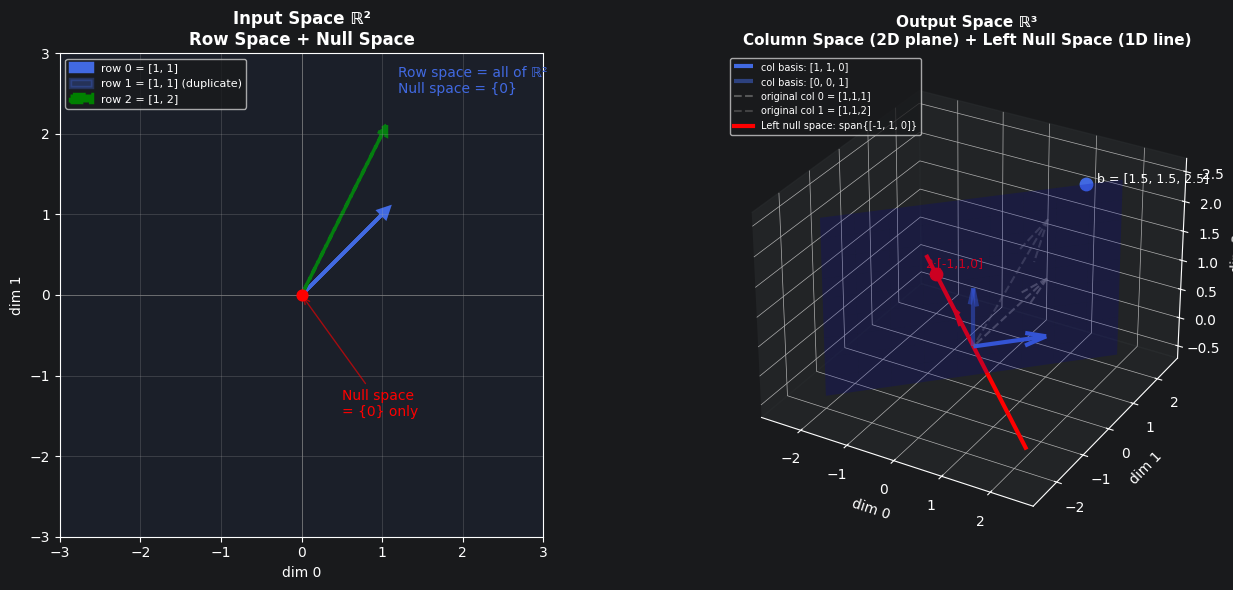

In [24]:
A = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0],
    [1.0, 2.0]
])

fig = plt.figure(figsize=(14, 6))

# ---- LEFT: 2D Input Space (Row Space + Null Space) ----
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_title('Input Space ℝ²\nRow Space + Null Space', fontsize=12, fontweight='bold')
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.5)
ax1.set_xlabel('dim 0')
ax1.set_ylabel('dim 1')

row0 = A[0].numpy()
row1 = A[1].numpy()
row2 = A[2].numpy()

ax1.arrow(0, 0, row0[0], row0[1], head_width=0.12, head_length=0.12,
          color='royalblue', linewidth=2.5, label='row 0 = [1, 1]')
ax1.arrow(0, 0, row1[0], row1[1], head_width=0.12, head_length=0.12,
          color='royalblue', linewidth=2.5, alpha=0.3, label='row 1 = [1, 1] (duplicate)')
ax1.arrow(0, 0, row2[0], row2[1], head_width=0.12, head_length=0.12,
          color='green', linewidth=2.5, linestyle='--', label='row 2 = [1, 2]')

ax1.fill_between([-3, 3], [-3, -3], [3, 3], alpha=0.07, color='royalblue')
ax1.text(1.2, 2.5, 'Row space = all of ℝ²\nNull space = {0}',
         fontsize=10, color='royalblue')

ax1.scatter(0, 0, color='red', s=60, zorder=5)
ax1.annotate('Null space\n= {0} only', xy=(0, 0), xytext=(0.5, -1.5),
             fontsize=10, color='red',
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

ax1.legend(fontsize=8, loc='upper left')

# ---- RIGHT: 3D Output Space (Column Space + Left Null Space) ----
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.set_title('Output Space ℝ³\nColumn Space (2D plane) + Left Null Space (1D line)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('dim 0')
ax2.set_ylabel('dim 1')
ax2.set_zlabel('dim 2')

# plane equation: x = y (z can be anything)
xx, zz = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-0.5, 2.5, 10))
yy = xx  # the plane x = y
ax2.plot_surface(xx, yy, zz, alpha=0.2, color='blue')

# column space basis vectors
basis0 = np.array([1.0, 1.0, 0.0])
basis1 = np.array([0.0, 0.0, 1.0])
ax2.quiver(0, 0, 0, basis0[0], basis0[1], basis0[2],
           color='royalblue', linewidth=3, label='col basis: [1, 1, 0]')
ax2.quiver(0, 0, 0, basis1[0], basis1[1], basis1[2],
           color='royalblue', linewidth=3, alpha=0.5, label='col basis: [0, 0, 1]')

# original columns (dashed, to show they lie on the same plane)
col0 = A[:, 0].numpy()
col1 = A[:, 1].numpy()
ax2.quiver(0, 0, 0, col0[0], col0[1], col0[2],
           color='gray', linewidth=1.5, linestyle='--', alpha=0.6, label='original col 0 = [1,1,1]')
ax2.quiver(0, 0, 0, col1[0], col1[1], col1[2],
           color='gray', linewidth=1.5, linestyle='--', alpha=0.4, label='original col 1 = [1,1,2]')

# left null space: span of [-1, 1, 0] -- perpendicular to the x=y plane
null_left = np.array([-1.0, 1.0, 0.0])
t_vals = np.linspace(-2.5, 2.5, 2)
ax2.plot(t_vals * null_left[0], t_vals * null_left[1], t_vals * null_left[2],
         color='red', linewidth=3, label='Left null space: span{[-1, 1, 0]}')
ax2.quiver(0, 0, 0, null_left[0], null_left[1], null_left[2],
           color='red', linewidth=2)

# sample output
x_sample = torch.tensor([0.5, 1.0])
b = A @ x_sample
ax2.scatter(b[0].item(), b[1].item(), b[2].item(),
            color='royalblue', s=80, zorder=5)
ax2.text(b[0].item()+0.15, b[1].item()+0.15, b[2].item(),
         f'b = [1.5, 1.5, 2.5]', fontsize=9)

# left null vector
y_sample = 2.0 * null_left
ax2.scatter(y_sample[0], y_sample[1], y_sample[2],
            color='red', s=80, zorder=5)
ax2.text(y_sample[0]-0.3, y_sample[1]+0.1, y_sample[2],
         f'2·[-1,1,0]', fontsize=9, color='red')

ax2.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

* This *A* is like a `W_Q` or `W_K` projection: it maps from 2D input to 3D output, preserving all input information (no null space), but its outputs are constrained to a 2D plane inside the 3D output space (non-trivial left null space)--some output patterns are unreachable.

```
A = C @ R where:
  C = r independent columns of A  (m×r)
  R = matrix with r independent rows in reduced form  (r×n)

For A = [[1, 1], [1, 1], [1, 2]]  (3×2, rank r=2):

    C = [[1, 1],         (columns 0 and 1 of A -- both are independent)
         [1, 1],
         [1, 2]]

    R = [[1, 0],         (A's rows are already independent;
         [0, 1]]          R is identity because no reduction needed)
```

```
Aᵀ = [[1, 1, 1],
      [1, 1, 2]]   (2×3, rank 2)

    Aᵀ reduces to Rₐᵀ = [[1, 1, 0],
                        [0, 0, 1]]

    col(A) = span{rows of Rₐᵀ} = span{[1,1,0], [0,0,1]}
    This is the same plane as span{[1,1,1], [1,1,2]} but with a cleaner basis.
```

```
row(A) = row(R) = all of R^2    -> basis from rows of R
null(A) = null(R) = {[0, 0]}    -> solve R @ x = 0

col(A) = col(C) = span{[1,1,0], [0,0,1]}    -> basis from columns of C
null(A^T)  = span{[-1,1,0]}                 -> solve Cᵀ @ y = 0
```

#### 3.2 Linear Independence in Multi-Head Attention

* Let *V* be a set of vectors. Let $\vec{v_1}$ and $\vec{v_2}$ be any two vectors in *V*, and let *k* be any scalar. If the sum $\vec{v_1}$ + $\vec{v_2}$ is also in *V*, then we say *V* is **closed under vector addition**. If the product $k\vec{v_1}$ is also in *V*, then we say *V* is **closed under scalar multiplication**.

* A **subset** of *V* is any collection of vectors in *V*. If the set *U* is any collection of elements of the set *V*, then *U* is a subset of *V*, $U \subseteq V$

* set $U$ is a **subspace** of a Euclidean vector space $\mathbb{R}^n$ if (1) *U* is a nonempty subset of $\mathbb{R}^n$, (2) if *U* is closed under vector addition, and (3) if *U* is closed under scalar multiplication

If $S = {\vec{v_1}, \vec{v_2}, \dots, \vec{v_n}}$ is a set of two or more vectors in a vector space *V*, then *S* is said to be **linearly independent set** if no vectors in *S* can be expressed as a linear combination of the other vectors in the set. A set that is not linearly independent is said to be **linearly dependent**.

A set of vectors is a **basis** for a space if (1) the vectors span the space, and (2) are linearly independent. The number of the vectors in a basis of a space is called the **dimension** of the space, and this number is unique.

The **rank** of a matrix *A* is the dimension of the **column space** of *A*.

In [19]:
import torch

d_model, d_k = 6, 3

# Head 1's query projection
W_Q1 = torch.tensor([
    [ 0.3,  0.1, -0.2,  0.0,  0.4,  0.2],
    [-0.1,  0.5,  0.1, -0.3,  0.0,  0.2],
    [ 0.2, -0.1,  0.3,  0.1, -0.2,  0.0]
])

# Head 2: independent -- rows span new directions
W_Q2 = torch.tensor([
    [ 0.1,  0.4,  0.0,  0.2, -0.1,  0.3],
    [ 0.5, -0.2,  0.1,  0.0,  0.3, -0.1],
    [-0.3,  0.0,  0.2,  0.4,  0.1, -0.2]
])

# Head 3: dependent -- rows are scalar multiples of Head 1's rows
W_Q3 = 2.0 * W_Q1

# Head 4: dependent -- rows are linear combinations of Head 1's rows
W_Q4 = torch.zeros_like(W_Q1)
W_Q4[0] = W_Q1[0] + W_Q1[1]           # row0 = row0_H1 + row1_H1
W_Q4[1] = 0.5 * W_Q1[0] - W_Q1[2]     # row1 = 0.5*row0_H1 - row2_H1
W_Q4[2] = W_Q1[0] + W_Q1[1] + W_Q1[2] # row2 = row0_H1 + row1_H1 + row2_H1

stacks = {
    "Heads 1 & 2 (independent)":     torch.cat([W_Q1, W_Q2], dim=0),
    "Heads 1 & 3 (scalar multiple)": torch.cat([W_Q1, W_Q3], dim=0),
    "Heads 1 & 4 (linear combo)":    torch.cat([W_Q1, W_Q4], dim=0),
}

print("Rank of stacked W_Q (max = 6):")
for label, stacked in stacks.items():
    print(f"  {label}:  rank = {torch.linalg.matrix_rank(stacked).item()}")

# a single token vector
x = torch.tensor([0.5, -0.2, 0.8, 0.1, -0.6, 0.3])

W_Q_list = [W_Q1, W_Q2, W_Q3, W_Q4]
queries = [W @ x for W in W_Q_list]

print("\nQueries from the same token:")
for i, q in enumerate(queries, 1):
    print(f"  Head {i}: {q}")

Rank of stacked W_Q (max = 6):
  Heads 1 & 2 (independent):  rank = 6
  Heads 1 & 3 (scalar multiple):  rank = 3
  Heads 1 & 4 (linear combo):  rank = 3

Queries from the same token:
  Head 1: tensor([-0.2100, -0.0400,  0.4900])
  Head 2: tensor([ 0.1400,  0.1600, -0.0700])
  Head 3: tensor([-0.4200, -0.0800,  0.9800])
  Head 4: tensor([-0.2500, -0.5950,  0.2400])


In [20]:
q1, q4 = queries[0], queries[3]
checks = [
    (0, q1[0] + q1[1],          f"q1[0] + q1[1]"),
    (1, 0.5 * q1[0] - q1[2],    f"0.5*q1[0] - q1[2]"),
    (2, q1[0] + q1[1] + q1[2],  f"q1[0] + q1[1] + q1[2]"),
]

print("\nHead 4 is a fixed function of Head 1 (holds for ANY input):")
for dim, expected, formula in checks:
    print(f"  q4[{dim}] = {formula} = {expected:.4f}  (actual: {q4[dim]:.4f})")


Head 4 is a fixed function of Head 1 (holds for ANY input):
  q4[0] = q1[0] + q1[1] = -0.2500  (actual: -0.2500)
  q4[1] = 0.5*q1[0] - q1[2] = -0.5950  (actual: -0.5950)
  q4[2] = q1[0] + q1[1] + q1[2] = 0.2400  (actual: 0.2400)


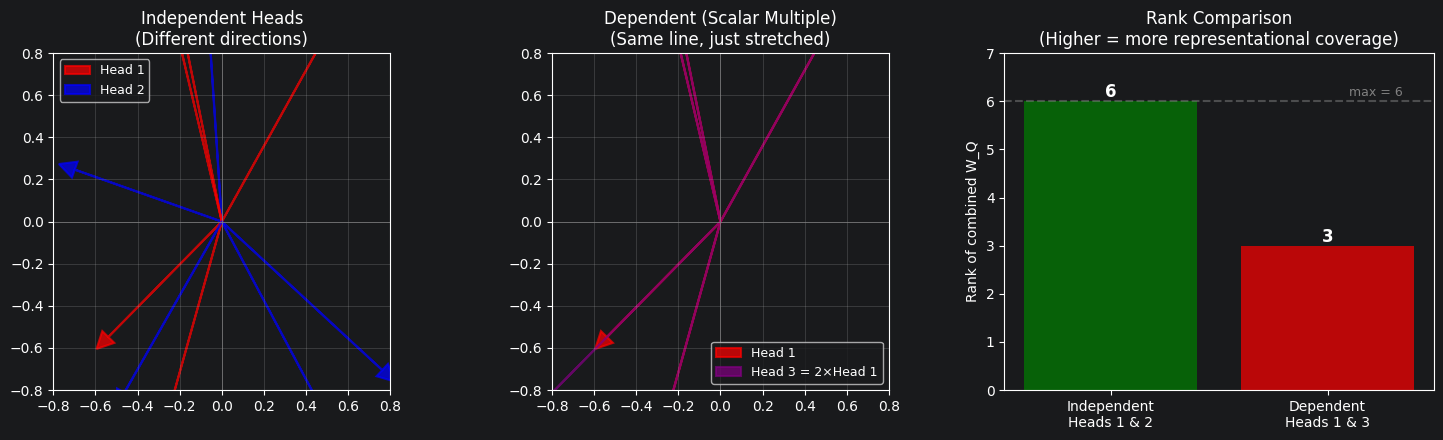

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# We'll show the query vectors for 5 different input tokens
torch.manual_seed(42)
tokens = torch.randn(5, d_model)

q1_all = tokens @ W_Q1.T
q2_all = tokens @ W_Q2.T
q3_all = tokens @ W_Q3.T

# Project to 2D (first two principal components for visualization)
# Simplification: just show dim 0 vs dim 1

# ---- Left: Independent heads (q1 vs q2) ----
ax = axes[0]
for i in range(5):
    ax.arrow(0, 0, q1_all[i, 0], q1_all[i, 1],
             head_width=0.08, head_length=0.08, color='red', alpha=0.7, linewidth=1.5)
    ax.arrow(0, 0, q2_all[i, 0], q2_all[i, 1],
             head_width=0.08, head_length=0.08, color='blue', alpha=0.7, linewidth=1.5)
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Independent Heads\n(Different directions)', fontsize=12)
ax.legend(['Head 1', 'Head 2'], fontsize=9)

# ---- Middle: Dependent (scalar multiple) ----
ax2 = axes[1]
for i in range(5):
    ax2.arrow(0, 0, q1_all[i, 0], q1_all[i, 1],
              head_width=0.08, head_length=0.08, color='red', alpha=0.7, linewidth=1.5)
    ax2.arrow(0, 0, q3_all[i, 0], q3_all[i, 1],
              head_width=0.08, head_length=0.08, color='purple', alpha=0.7, linewidth=1.5)
ax2.set_xlim(-0.8, 0.8)
ax2.set_ylim(-0.8, 0.8)
ax2.set_aspect('equal')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.axvline(x=0, color='gray', linewidth=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_title('Dependent (Scalar Multiple)\n(Same line, just stretched)', fontsize=12)
ax2.legend(['Head 1', 'Head 3 = 2×Head 1'], fontsize=9)

# ---- Right: Rank comparison ----
ax3 = axes[2]
# Stack W_Q1 and W_Q2: full rank (6 independent rows → rank 6)
combined_independent = torch.cat([W_Q1, W_Q2], dim=0)  # (6, 6)
# Stack W_Q1 and W_Q3: rank deficient (only 3 independent rows → rank 3)
combined_dependent = torch.cat([W_Q1, W_Q3], dim=0)    # (6, 6)

ranks = [
    torch.linalg.matrix_rank(combined_independent).item(),
    torch.linalg.matrix_rank(combined_dependent).item()
]
bars = ax3.bar(['Independent\nHeads 1 & 2', 'Dependent\nHeads 1 & 3'], ranks,
               color=['green', 'red'], alpha=0.7)
ax3.bar_label(bars, fontsize=12, fontweight='bold')
ax3.set_ylabel('Rank of combined W_Q', fontsize=10)
ax3.set_title('Rank Comparison\n(Higher = more representational coverage)', fontsize=12)
ax3.set_ylim(0, 7)
ax3.axhline(y=6, color='gray', linestyle='--', alpha=0.5)
ax3.text(1.1, 6.1, 'max = 6', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

Two attention heads are independent if their stacked projection matrices (`W_Q, W_K, W_V`) have full rank -- the rows of one cannot be expressed as linear combinations of the other's. Each head contributes directions the other cannot reach.

Dependent query projections share the same subspace. With different keys, attention weights can still differ, but the dependent head cannot discover patterns the independent head missed -- the rank of the stacked projections sets the ceiling on unique directions.

Independent heads expand what the model can represent: rank goes up, capacity increases. Dependent heads consume parameters without expanding capacity: rank stays flat.
* In the example above: stacking `W_Q1` and `W_Q2` gives rank 6 (full -- two independent heads). Stacking `W_Q1` with `W_Q3` or `W_Q4` gives rank 3 (flat -- the second head adds no new subspace, only scaled or remixed versions of Head 1's directions).

In [ ]:
# symmetry, eigenvalues/eigenvectors

## Calculus

**Fundamental Theorem of Calculus**:
$$\int_a^b f'(x) \, dx = f(b) - f(a)$$
> the integral of a differential form is evaluated on the boundary
---

**Fundamental Theorem for Line Integrals**:

$$\int_C \nabla f \cdot \hat{t} \, ds = f(\vec{r}(b)) - f(\vec{r}(a))$$

Or in components:

$$\int_{(a_1, a_2)}^{(b_1, b_2)} f_{x} \, dx + f_{y} \, dy  = f(b_1, b_2) - f(a_1, a_2)$$

Where:
- $C$ is a curve from $\vec{r}(a)$ to $\vec{r}(b)$
- $\nabla f = <f_{x}, f_{y}>$ is the gradient of $F$ (partial derivatives of $F$)
- $\hat{t}$ is the unit tangent vector along $C$

---

**Green's Theorem (Tangential/Circulation Form)**
$$\iint_D \nabla x \vec{F} \cdot \hat{k} \, dA = \oint_{\partial D} \vec{F} \cdot \hat{t} ds $$

Where
- $D$ = region in the plane
- $\partial D$ = boundary of $D$ (closed curve)
- $\hat{k}$ = unit vector perpendicular to the plane
- $ds$ = arc length element
- $\nabla \times \vec{F} = \frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y}$ (scalar curl)

---

**Green's Theorem (Normal/Flux Form)**
$$\iint_D \nabla \cdot \vec{F} \, dA = \oint_{\partial D} \vec{F} \cdot \hat{n} \, ds$$
Where:
- $\hat{n}$ = outward unit normal vector
- $\nabla \cdot \vec{F} = \frac{\partial F_x}{\partial x} + \frac{\partial F_y}{\partial y}$ (divergence of $\vec{F}$)
<br> The total divergence (source strength) inside $D$ equals the net flux outward through its boundary. *Divergence Theorem one dimension down*.

---

**Stokes Theorem**
$$\iint_S (\nabla \times \vec{F}) \cdot \hat{n} \, dS = \oint_{\partial S} \vec{F} \cdot d\vec{r}$$
Where:
- $S$ is an oriented surface in $\mathbb{R}^3$
- $\partial S$ is the closed curve bounding $S$
- $\hat{n}$ is the unit normal vector
- $dS$ is the surface area element
- $d\vec{r} = \hat{t} \, ds$
<br> The circulation of $\vec{F}$ around $\partial S$ equals the total curl (rotation) through $S$.

---

**Divergence Theorem (Gauss's Theorem)**

$$\iiint_E \nabla \cdot \vec{F} \, dV = \iint_{\partial E} \vec{F} \cdot \hat{n} \, dS$$
Where:
- $E$ is a solid in $\mathbb{R}^3$
- $\partial E$ is the closed surface bounding $V$
- $\hat{n}$ is the outward unit normal vector
- $dS$ is the surface area element
<br> The total divergence (source strength) inside $V$ equals the net flux outward through its boundary.

In [ ]:
# chain rule

In [ ]:
# gradient descent

In [ ]:
# backpropagation

In [ ]:
# universal approximation

## Other

In [ ]:
# Jacobian

In [ ]:
# differential equations